# PBMC68k evaluation

This notebook evaluates the frozen BayesGM output. It does not train the model, tune parameters, or select a checkpoint. The test set is loaded here only after training is complete.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import evaluate as ev

SPLIT_DIR = Path("data/splits")
RESULT_DIR = Path("results/bayesgm")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Split directory:", SPLIT_DIR)
print("Result directory:", RESULT_DIR)

/home/lh987/.conda/envs/bayesgm310/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Split directory: data/splits
Result directory: results/bayesgm


## 1. Protocol audit

Check that the three data splits are disjoint, that training did not load the test set, and that the gene order matches.

In [3]:
audit = ev.audit_protocol(SPLIT_DIR, RESULT_DIR)
manifest = audit["manifest"]
config = audit["run_config"]

display(pd.Series({
    "train_cells": manifest["n_cells"]["train"],
    "validation_cells": manifest["n_cells"]["validation"],
    "test_cells": manifest["n_cells"]["test"],
    "genes": manifest["n_genes"],
    "model_selection": config["model_selection"],
    "test_loaded_during_training": config["final_test_loaded_during_training"],
}, name="value").to_frame())

,value
train_cells,49376
validation_cells,5487
test_cells,13716
genes,17189
model_selection,validation_ilisi_pca20 only
test_loaded_during_training,False


## 2. Load the test data

In [4]:
real, generated, genes, test_raw = ev.load_final_test_and_generated(
    SPLIT_DIR, RESULT_DIR, target_sum=1e4
)

print("Real:", real.shape)
print("Generated:", generated.shape)
assert real.shape[1] == generated.shape[1] == len(genes)

Real: (13716, 17189)
Generated: (2000, 17189)


## 3. Metrics

PCA20 iLISI and PCA50 MMD are computed from a joint PCA of real and generated full-gene expression.

In [5]:
metrics = ev.compute_quantitative_metrics(
    real, generated, n_eval=2000, mmd_n_eval=500, seed=42
)
ev.save_metrics(metrics, RESULT_DIR)
display(pd.Series(metrics, name="value").to_frame())

/home/lh987/.conda/envs/bayesgm310/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-24 16:17:27.053539: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-24 16:17:27.134893: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-24 16:17:27.148013: E tensorflow/stream_executo

,value
test_ilisi_pca20,0.824019
test_mmd_pca50,0.180580
test_real_zero_frac,0.968482
generated_zero_frac,0.304853
test_real_cell_sum_mean,1366.166870
generated_cell_sum_mean,1409.160522
test_gene_mean_corr,0.998870
test_cells_used,2000.000000
mmd_cells_used,500.000000
evaluation_seed,42.000000


## 4. UMAP

/home/lh987/.conda/envs/bayesgm310/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


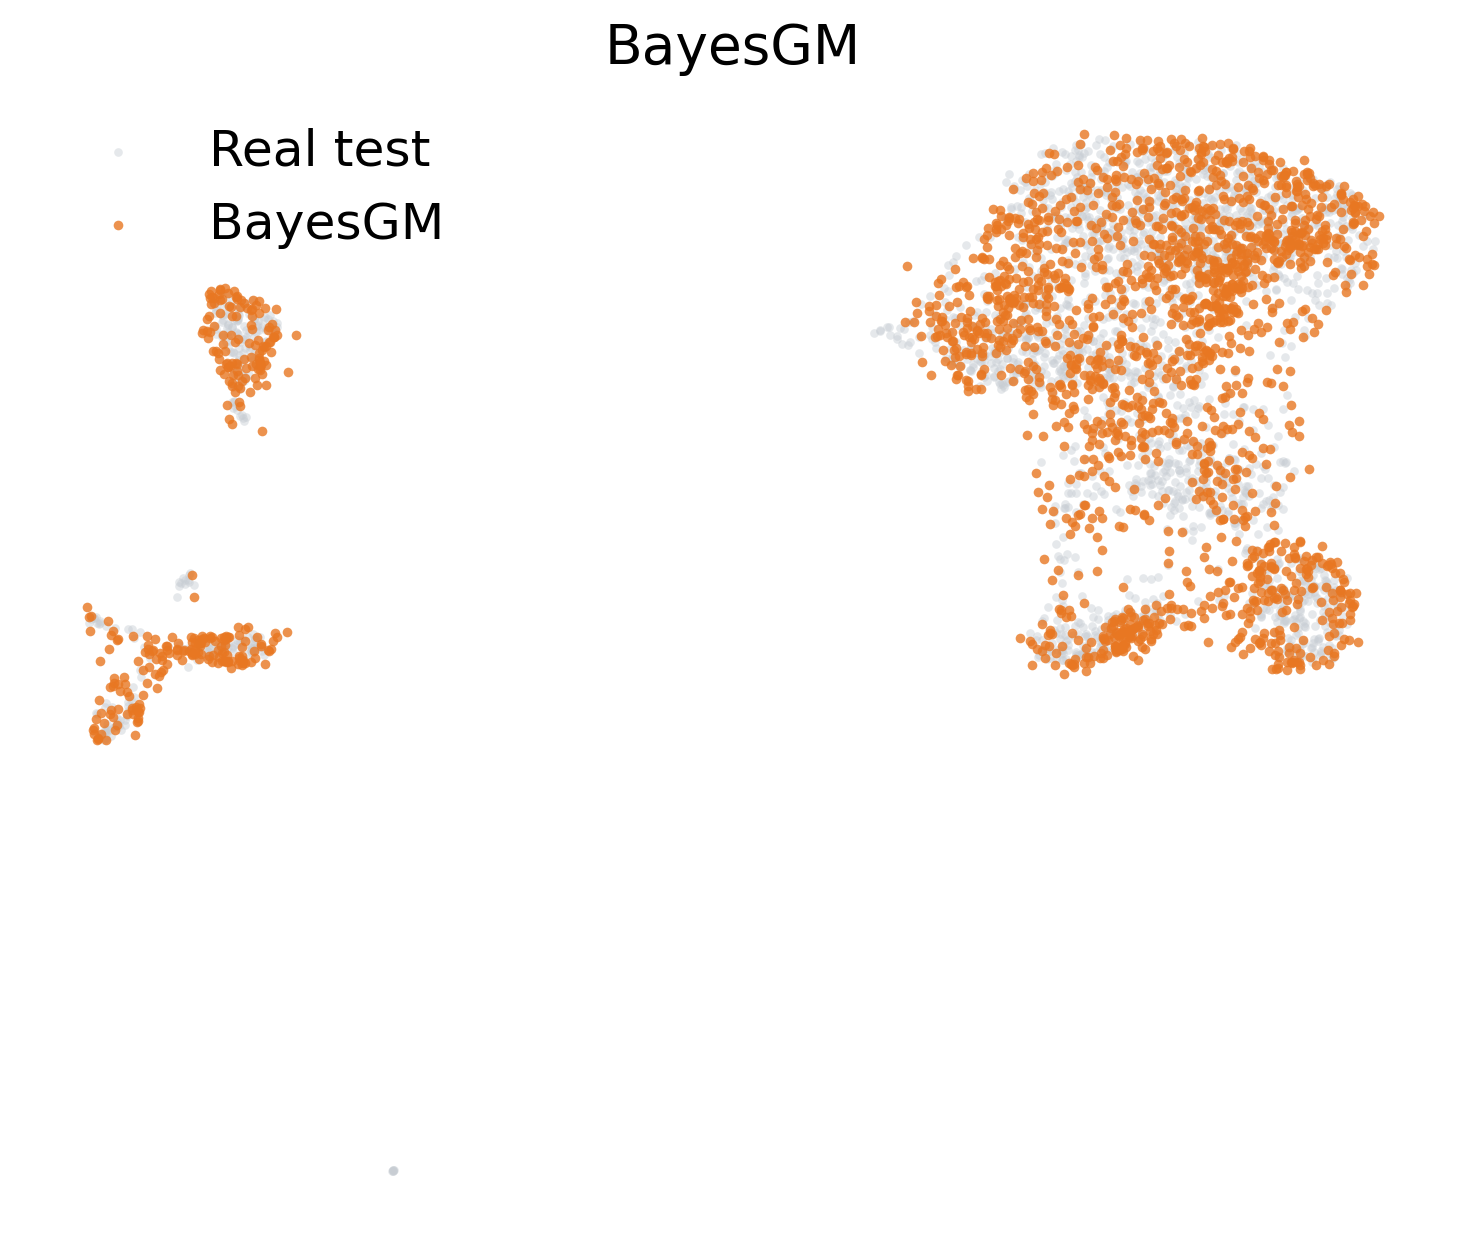

In [6]:
embedding = ev.prepare_embedding(real, generated, n_plot=2000, seed=42)
umap_path = ev.plot_umap(embedding, PLOT_DIR)
display(Image(filename=str(umap_path)))

## 5. Expression checks

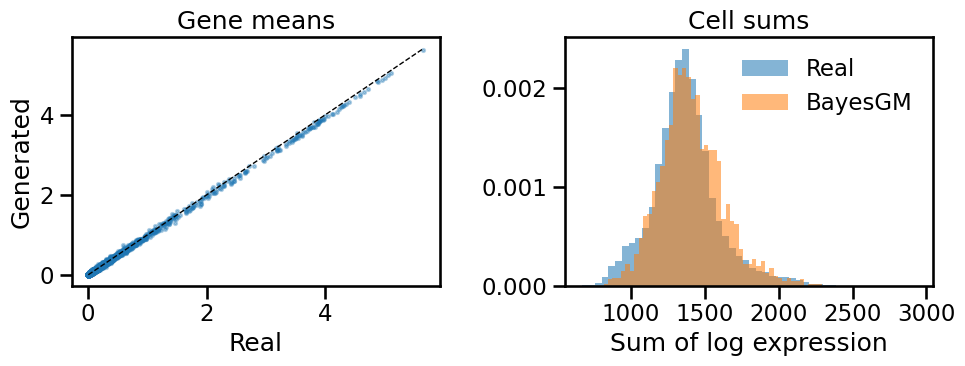

In [7]:
real_gene_mean = real.mean(axis=0)
generated_gene_mean = generated.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(real_gene_mean, generated_gene_mean, s=5, alpha=0.35)
limit = max(real_gene_mean.max(), generated_gene_mean.max())
axes[0].plot([0, limit], [0, limit], "--", color="black", linewidth=1)
axes[0].set(xlabel="Real", ylabel="Generated", title="Gene means")

axes[1].hist(real.sum(axis=1), bins=50, alpha=0.55, label="Real", density=True)
axes[1].hist(generated.sum(axis=1), bins=50, alpha=0.55, label="BayesGM", density=True)
axes[1].set(title="Cell sums", xlabel="Sum of log expression")
axes[1].legend(frameon=False)

plt.tight_layout()
distribution_path = PLOT_DIR / "distributions.png"
plt.savefig(distribution_path, dpi=220, bbox_inches="tight")
plt.show()